# Moving up and down the pyramid

Every dataset on the hub is stored as a pyramid: the same field written out
at a series of HEALPix levels, each one four times coarser than the last.
Choosing a level is normally all you need to do, and the number in the URL
is the whole of the API.

Sometimes you need to do it yourself, in memory, on a field you have already
computed or selected. Nested ordering makes that a reshape. The four
children of cell `i` at level `k` are cells `4i`, `4i+1`, `4i+2` and `4i+3`
at level `k+1`, always, with no lookup table. Combine that with equal areas
and coarsening by one level is `coarsen(cell=4).mean()`.

*The figure is saved with this notebook. Run the cells in order, from the top, to compute it again. The same example on the web: [Moving up and down the pyramid](https://waterpark.dkrz.de/docs/examples/07_pyramid_levels/).*

## What the store says it did

The pyramid levels are not anonymous. grid-doctor records how each one was
made, so the claim this example is about to check is written down in the
file rather than assumed.

In [ ]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from healpix_geo import nested

S3 = {"anon": True, "endpoint_url": "https://s3.waterpark.dkrz.de"}
FINE = "s3://reanalysis/healpix/era5/P1M/level_5.zarr"
COARSE = "s3://reanalysis/healpix/era5/P1M/level_4.zarr"

fine = xr.open_zarr(FINE, storage_options=S3, chunks=None)
coarse = xr.open_zarr(COARSE, storage_options=S3, chunks=None)

for name, store in (("fine", fine), ("coarse", coarse)):
    print(f"{name:6s} level {store.attrs['healpix_level']}, "
          f"{store.sizes['cell']:6d} cells, "
          f"method {store.attrs.get('grid_doctor_method', 'unrecorded')}, "
          f"from level {store.attrs.get('grid_doctor_coarsened_from_level', '-')}")

In [ ]:
month = "2021-07"
fine_map = fine["tas"].sel(time=month).squeeze().load()
coarse_map = coarse["tas"].sel(time=month).squeeze().load()

## Coarsening by hand

One line, with one trap in front of it. Coordinates coarsen too, and the
average of four longitudes is not the longitude of anything: four cells
that straddle the dateline average to somewhere near Greenwich. Drop every
coordinate before you coarsen and recompute them afterwards from the new
cell indices, which costs nothing.

In [ ]:
derived = fine_map.drop_vars(list(fine_map.coords)).coarsen(cell=4).mean()

cells = np.arange(derived.sizes["cell"], dtype="uint64")
lon, lat = nested.healpix_to_lonlat(cells, coarse.attrs["healpix_level"])
derived = derived.assign_coords(
    cell=("cell", cells.astype("int64")),
    longitude=("cell", np.asarray(lon)),
    latitude=("cell", np.asarray(lat)),
)

print(f"derived {derived.sizes['cell']} cells from {fine_map.sizes['cell']}")

## Does it match what the pyramid stored?

Conservative remapping on an equal-area grid *is* the plain mean of the
four children, so the two should agree to floating point. Checking is
cheap, and the check is worth keeping: it catches a pyramid built by
subsampling, one written in ring ordering, and one whose levels came from
different source data.

In [ ]:
residual = derived.values - coarse_map.values

print(f"max |difference| {np.abs(residual).max():.3e} K")
print(f"rms  difference  {np.sqrt(np.mean(residual**2)):.3e} K")
print(f"field range      {float(coarse_map.min()):.1f} to {float(coarse_map.max()):.1f} K")

## The plot

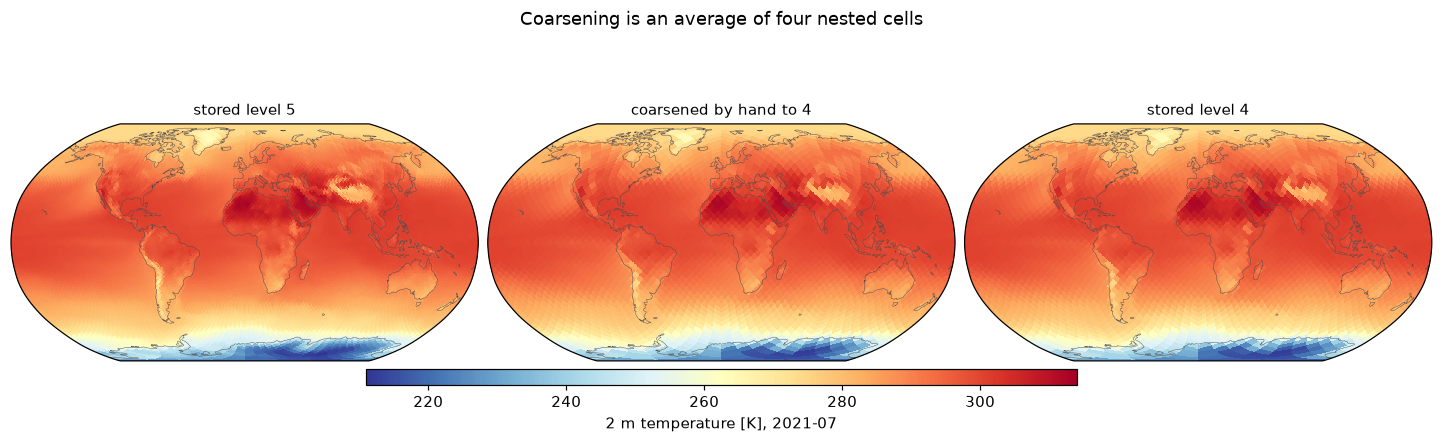

In [ ]:
def rasterize(values, level, nlon=720, nlat=360):
    lon = np.linspace(-180, 180, nlon)
    lat = np.linspace(90, -90, nlat)
    mesh_lon, mesh_lat = np.meshgrid(lon, lat)
    cells = nested.lonlat_to_healpix(mesh_lon.ravel(), mesh_lat.ravel(), level)
    return np.asarray(values)[cells.astype("int64")].reshape(mesh_lat.shape), lon, lat


panels = [
    (f"stored level {fine.attrs['healpix_level']}", fine_map.values,
     fine.attrs["healpix_level"]),
    (f"coarsened by hand to {coarse.attrs['healpix_level']}", derived.values,
     coarse.attrs["healpix_level"]),
    (f"stored level {coarse.attrs['healpix_level']}", coarse_map.values,
     coarse.attrs["healpix_level"]),
]
vmin = float(min(v.min() for _, v, _ in panels))
vmax = float(max(v.max() for _, v, _ in panels))

fig = plt.figure(figsize=(13, 3.9), layout="constrained")
for index, (title, values, level) in enumerate(panels, start=1):
    raster, lon, lat = rasterize(values, level)
    ax = fig.add_subplot(1, 3, index, projection=ccrs.Robinson())
    ax.coastlines(linewidth=0.3, color="0.3")
    ax.set_global()
    mesh = ax.pcolormesh(lon, lat, raster, cmap="RdYlBu_r", vmin=vmin, vmax=vmax,
                         shading="auto", transform=ccrs.PlateCarree())
    ax.set_title(title, fontsize=10)

fig.colorbar(mesh, ax=fig.axes, orientation="horizontal", shrink=0.5,
             aspect=45, pad=0.02, label=f"2 m temperature [K], {month}")
fig.suptitle("Coarsening is an average of four nested cells", fontsize=12)

fig.savefig("07_pyramid_levels.png", dpi=110, bbox_inches="tight", facecolor="white")
plt.show()

## Going the other way

Refining is the same identity read backwards, and it is
`np.repeat(values, 4)`: every child inherits its parent's value. That is
nearest neighbour upsampling, not interpolation, and it is what you want
when you need a coarse field on a fine cell axis in order to subtract it
from something. It is not what you want if you need a smooth field, in
which case `nested.bilinear_interpolation` gives you weights.

The general shift is two bits per level: the level `k` parent of a level
`n` cell is `cell >> (2 * (n - k))`. That one expression is behind every
cross-level operation in the hub, including the region selection in the
[regional data guide](https://waterpark.dkrz.de/docs/working-with-data/) and the comparison in the
[next example](https://waterpark.dkrz.de/docs/examples/08_cross_dataset/).

> **Note: When the residual is not zero**
>
> Conservative coarsening of a linear quantity on an equal-area grid is
> exact. It is not exact for a quantity that was already an average over
> something else, for a masked field where some children are missing, or
> for anything computed non-linearly from the field, such as a maximum
> or a threshold exceedance. For those, coarsen the inputs and recompute
> rather than coarsening the answer.